In [1]:
import sys

print(sys.executable)
print(sys.version)

C:\ProgramData\miniconda3\envs\meongjaguk\python.exe
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]


In [2]:
##%pip install osmnx

In [157]:
##%pip install matplotlib

In [159]:
##%pip install xgboost

In [4]:
import osmnx as ox
import matplotlib

print("OSMnx:", ox.__version__)
print("matplotlib:", matplotlib.__version__)

OSMnx: 2.1.1
matplotlib: 3.11.2


In [5]:
import sys

!{sys.executable} -m pip install matplotlib

In [24]:
import matplotlib

print(matplotlib.__version__)
print(matplotlib.__file__)

3.11.2
C:\ProgramData\miniconda3\envs\meongjaguk\Lib\site-packages\matplotlib\__init__.py


In [7]:
latitude = 37.5665
longitude = 126.9780

G = ox.graph_from_point(
    (latitude, longitude),
    dist=1000,
    network_type="walk"
)

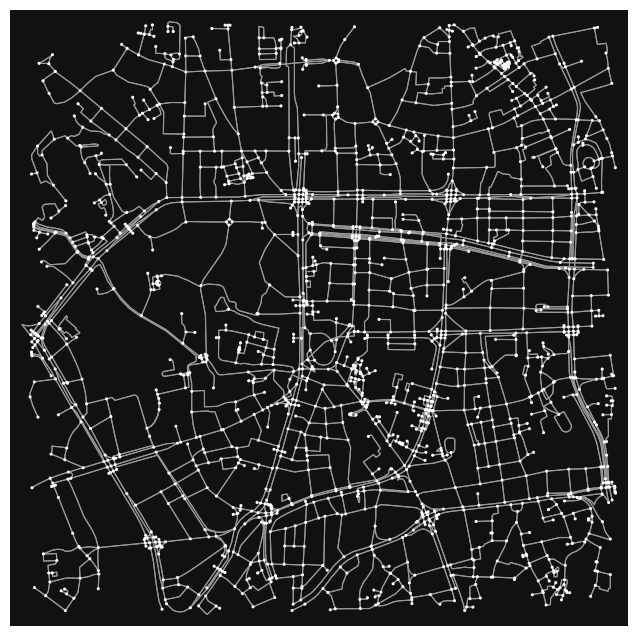

In [8]:
fig, ax = ox.plot_graph(
    G,
    node_size=5,
    edge_linewidth=0.8
)

In [10]:
start_node = ox.distance.nearest_nodes(
    G,
    X=longitude,
    Y=latitude
)
print("시작 노드:", start_node)

시작 노드: 3806615943


In [11]:
import networkx as nx

# 시작점에서 약 500~700m 떨어진 노드들을 후보로 찾기
candidate_nodes = []

for node, data in G.nodes(data=True):
    distance = ox.distance.great_circle(
        latitude,
        longitude,
        data["y"],
        data["x"]
    )

    if 500 <= distance <= 700:
        candidate_nodes.append(node)

print("후보 노드 개수:", len(candidate_nodes))

후보 노드 개수: 358


In [12]:
target_node = candidate_nodes[0]

route = nx.shortest_path(
    G,
    source=start_node,
    target=target_node,
    weight="length"
)

print("목적지 노드:", target_node)
print("경로 노드 개수:", len(route))
print("경로:", route)

목적지 노드: 287631232
경로 노드 개수: 16
경로: [3806615943, 3825649160, 3825649162, 3825649163, 11414286297, 5851251264, 11414286282, 5194567167, 5851251267, 1936511551, 436877019, 436877018, 1936511585, 13227969637, 1936511583, 287631232]


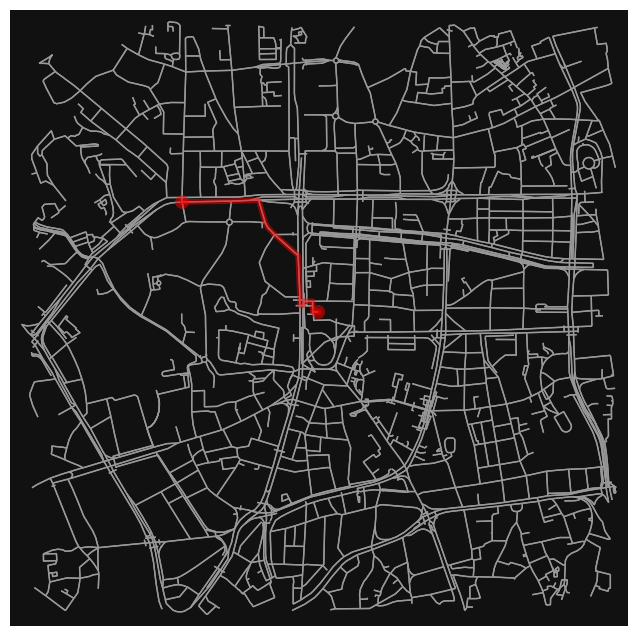

In [13]:
fig, ax = ox.plot_graph_route(
    G,
    route,
    route_linewidth=4,
    node_size=0
)

In [14]:
waypoint_a = candidate_nodes[0]
waypoint_b = candidate_nodes[len(candidate_nodes) // 2]

route_1 = nx.shortest_path(
    G,
    source=start_node,
    target=waypoint_a,
    weight="length"
)

route_2 = nx.shortest_path(
    G,
    source=waypoint_a,
    target=waypoint_b,
    weight="length"
)

route_3 = nx.shortest_path(
    G,
    source=waypoint_b,
    target=start_node,
    weight="length"
)

loop_route = route_1 + route_2[1:] + route_3[1:]

print("전체 경로 노드 개수:", len(loop_route))

전체 경로 노드 개수: 63


In [15]:
route_distance = 0

for u, v in zip(loop_route[:-1], loop_route[1:]):
    edge_data = G.get_edge_data(u, v)

    # 같은 두 노드 사이에 여러 edge가 있을 수 있으므로
    # 가장 짧은 edge 사용
    min_length = min(
        data["length"]
        for data in edge_data.values()
    )

    route_distance += min_length

print(f"총 거리: {route_distance:.0f} m")
print(f"총 거리: {route_distance / 1000:.2f} km")

총 거리: 2894 m
총 거리: 2.89 km


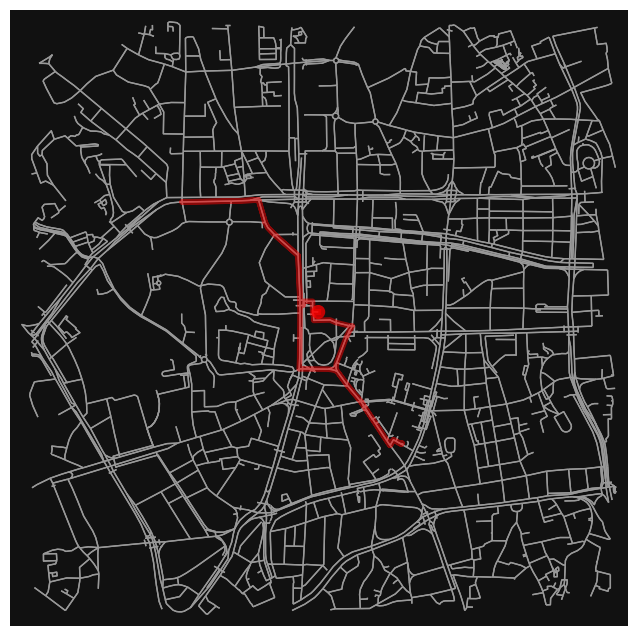

In [16]:
fig, ax = ox.plot_graph_route(
    G,
    loop_route,
    route_linewidth=4,
    node_size=0
)

In [17]:
import math

def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)

    diff_lon = math.radians(lon2 - lon1)

    x = math.sin(diff_lon) * math.cos(lat2)
    y = (
        math.cos(lat1) * math.sin(lat2)
        - math.sin(lat1) * math.cos(lat2) * math.cos(diff_lon)
    )

    bearing = math.degrees(math.atan2(x, y))

    return (bearing + 360) % 360

In [18]:
for node in candidate_nodes[:10]:
    node_data = G.nodes[node]

    bearing = calculate_bearing(
        latitude,
        longitude,
        node_data["y"],
        node_data["x"]
    )

    print(f"노드: {node}, 방향: {bearing:.1f}°")

노드: 287631232, 방향: 309.4°
노드: 287712330, 방향: 310.5°
노드: 436718742, 방향: 46.2°
노드: 436830302, 방향: 189.3°
노드: 436830303, 방향: 183.5°
노드: 436830304, 방향: 170.9°
노드: 436835632, 방향: 270.7°
노드: 436843958, 방향: 152.0°
노드: 436843959, 방향: 151.1°
노드: 436854093, 방향: 221.7°


In [19]:
target_bearings = [60, 180, 300]

waypoints = []

for target_bearing in target_bearings:
    best_node = None
    smallest_diff = float("inf")

    for node in candidate_nodes:
        node_data = G.nodes[node]

        bearing = calculate_bearing(
            latitude,
            longitude,
            node_data["y"],
            node_data["x"]
        )

        # 0°와 360° 경계를 고려한 각도 차이
        diff = abs((bearing - target_bearing + 180) % 360 - 180)

        if diff < smallest_diff:
            smallest_diff = diff
            best_node = node

    waypoints.append(best_node)

print("선택된 경유지:", waypoints)

선택된 경유지: [11233115541, 5484607796, 5863307785]


In [20]:
new_loop_route = []

route_nodes = [start_node] + waypoints + [start_node]

for i in range(len(route_nodes) - 1):
    section = nx.shortest_path(
        G,
        source=route_nodes[i],
        target=route_nodes[i + 1],
        weight="length"
    )

    if i == 0:
        new_loop_route.extend(section)
    else:
        new_loop_route.extend(section[1:])

print("새 경로 노드 개수:", len(new_loop_route))

새 경로 노드 개수: 106


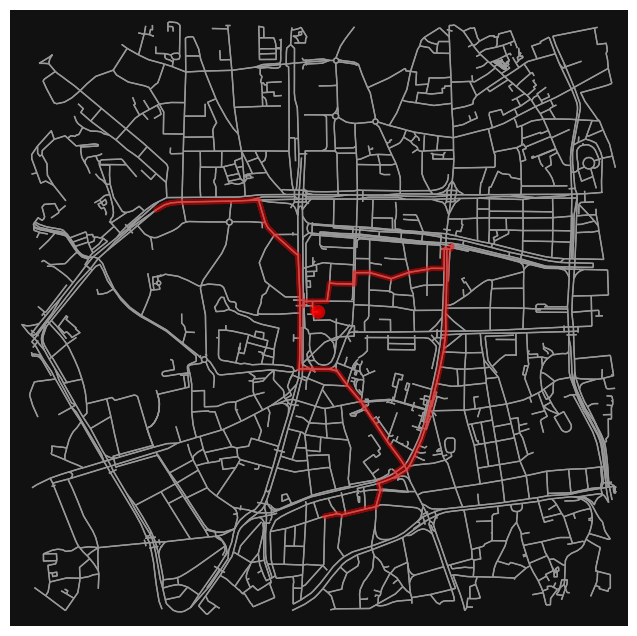

In [21]:
fig, ax = ox.plot_graph_route(
    G,
    new_loop_route,
    route_linewidth=4,
    node_size=0
)

In [22]:
new_route_distance = 0

for u, v in zip(new_loop_route[:-1], new_loop_route[1:]):
    edge_data = G.get_edge_data(u, v)

    min_length = min(
        data["length"]
        for data in edge_data.values()
    )

    new_route_distance += min_length

print(f"총 거리: {new_route_distance:.0f} m")
print(f"총 거리: {new_route_distance / 1000:.2f} km")

총 거리: 4635 m
총 거리: 4.63 km


In [23]:
from collections import Counter

route_edges = []

for u, v in zip(new_loop_route[:-1], new_loop_route[1:]):
    # 방향과 관계없이 같은 도로로 처리
    edge = tuple(sorted((u, v)))
    route_edges.append(edge)

edge_counts = Counter(route_edges)

duplicate_count = sum(
    count - 1
    for count in edge_counts.values()
    if count > 1
)

overlap_ratio = duplicate_count / len(route_edges) * 100

print("전체 이동 구간:", len(route_edges))
print("중복 이동 구간:", duplicate_count)
print(f"경로 중복률: {overlap_ratio:.1f}%")

전체 이동 구간: 105
중복 이동 구간: 24
경로 중복률: 22.9%


In [24]:
candidate_nodes_short = []

for node, data in G.nodes(data=True):
    distance = ox.distance.great_circle(
        latitude,
        longitude,
        data["y"],
        data["x"]
    )

    if 300 <= distance <= 500:
        candidate_nodes_short.append(node)

print("300~500m 후보 노드 개수:", len(candidate_nodes_short))

300~500m 후보 노드 개수: 311


In [25]:
def select_waypoints(candidate_nodes, target_bearings):
    waypoints = []

    for target_bearing in target_bearings:
        best_node = None
        smallest_diff = float("inf")

        for node in candidate_nodes:
            node_data = G.nodes[node]

            bearing = calculate_bearing(
                latitude,
                longitude,
                node_data["y"],
                node_data["x"]
            )

            diff = abs((bearing - target_bearing + 180) % 360 - 180)

            if diff < smallest_diff:
                smallest_diff = diff
                best_node = node

        waypoints.append(best_node)

    return waypoints

In [26]:
test_waypoints = select_waypoints(
    candidate_nodes_short,
    [60, 180, 300]
)

print("선택된 경유지:", test_waypoints)

선택된 경유지: [13732389934, 7985083475, 6072006691]


In [27]:
def generate_loop_route(start_node, waypoints):
    route_nodes = [start_node] + waypoints + [start_node]

    loop_route = []

    for i in range(len(route_nodes) - 1):
        section = nx.shortest_path(
            G,
            source=route_nodes[i],
            target=route_nodes[i + 1],
            weight="length"
        )

        if i == 0:
            loop_route.extend(section)
        else:
            loop_route.extend(section[1:])

    return loop_route

In [28]:
test_route = generate_loop_route(
    start_node,
    test_waypoints
)

print("경로 노드 개수:", len(test_route))

경로 노드 개수: 70


In [29]:
from collections import Counter

def analyze_route(route):
    total_distance = 0
    route_edges = []

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        min_length = min(
            data["length"]
            for data in edge_data.values()
        )

        total_distance += min_length

        # 반대 방향도 같은 도로로 취급
        route_edges.append(tuple(sorted((u, v))))

    edge_counts = Counter(route_edges)

    duplicate_count = sum(
        count - 1
        for count in edge_counts.values()
        if count > 1
    )

    overlap_ratio = (
        duplicate_count / len(route_edges) * 100
        if route_edges
        else 0
    )

    return {
        "distance_m": total_distance,
        "overlap_ratio": overlap_ratio
    }

In [30]:
result = analyze_route(test_route)

print(f"총 거리: {result['distance_m'] / 1000:.2f} km")
print(f"중복률: {result['overlap_ratio']:.1f}%")

총 거리: 3.31 km
중복률: 17.4%


In [31]:
bearing_sets = [
    [0, 120, 240],
    [30, 150, 270],
    [60, 180, 300],
    [90, 210, 330]
]

route_candidates = []

for bearings in bearing_sets:
    waypoints = select_waypoints(
        candidate_nodes_short,
        bearings
    )

    route = generate_loop_route(
        start_node,
        waypoints
    )

    analysis = analyze_route(route)

    route_candidates.append({
        "bearings": bearings,
        "distance_m": analysis["distance_m"],
        "overlap_ratio": analysis["overlap_ratio"],
        "route": route
    })

for i, candidate in enumerate(route_candidates, start=1):
    print(
        f"후보 {i} | "
        f"방향: {candidate['bearings']} | "
        f"거리: {candidate['distance_m'] / 1000:.2f} km | "
        f"중복률: {candidate['overlap_ratio']:.1f}%"
    )

후보 1 | 방향: [0, 120, 240] | 거리: 2.93 km | 중복률: 11.8%
후보 2 | 방향: [30, 150, 270] | 거리: 3.06 km | 중복률: 32.9%
후보 3 | 방향: [60, 180, 300] | 거리: 3.31 km | 중복률: 17.4%
후보 4 | 방향: [90, 210, 330] | 거리: 2.34 km | 중복률: 21.7%


In [35]:
from collections import defaultdict

def analyze_route(route):
    total_distance = 0
    edge_distances = defaultdict(list)

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        min_length = min(
            data["length"]
            for data in edge_data.values()
        )

        total_distance += min_length

        # 반대 방향도 같은 도로로 처리
        edge_key = tuple(sorted((u, v)))
        edge_distances[edge_key].append(min_length)

    duplicate_distance = 0

    for distances in edge_distances.values():
        if len(distances) > 1:
            duplicate_distance += sum(distances[1:])

    overlap_ratio = (
        duplicate_distance / total_distance * 100
        if total_distance > 0
        else 0
    )

    return {
        "distance_m": total_distance,
        "duplicate_distance_m": duplicate_distance,
        "overlap_ratio": overlap_ratio
    }

In [33]:
for i, candidate in enumerate(route_candidates, start=1):
    print(
        f"후보 {i} | "
        f"거리: {candidate['distance_m'] / 1000:.2f} km | "
        f"중복 거리: {candidate.get('duplicate_distance_m', 0):.0f} m | "
        f"중복률: {candidate['overlap_ratio']:.1f}%"
    )

후보 1 | 거리: 2.93 km | 중복 거리: 0 m | 중복률: 11.8%
후보 2 | 거리: 3.06 km | 중복 거리: 0 m | 중복률: 32.9%
후보 3 | 거리: 3.31 km | 중복 거리: 0 m | 중복률: 17.4%
후보 4 | 거리: 2.34 km | 중복 거리: 0 m | 중복률: 21.7%


In [38]:
route_candidates.append({
    "bearings": bearings,
    "distance_m": analysis["distance_m"],
    "duplicate_distance_m": analysis["duplicate_distance_m"],
    "overlap_ratio": analysis["overlap_ratio"],
    "route": route
})

KeyError: 'duplicate_distance_m'

In [37]:
test_analysis = analyze_route(test_route)

print(test_analysis)

{'distance_m': np.float64(3308.5674883862825), 'duplicate_distance_m': np.float64(593.1450619582623), 'overlap_ratio': np.float64(17.92754912935333)}


In [39]:
route_candidates = []

for bearings in bearing_sets:
    waypoints = select_waypoints(
        candidate_nodes_short,
        bearings
    )

    route = generate_loop_route(
        start_node,
        waypoints
    )

    analysis = analyze_route(route)

    route_candidates.append({
        "bearings": bearings,
        "distance_m": analysis["distance_m"],
        "duplicate_distance_m": analysis["duplicate_distance_m"],
        "overlap_ratio": analysis["overlap_ratio"],
        "route": route
    })

for i, candidate in enumerate(route_candidates, start=1):
    print(
        f"후보 {i} | "
        f"거리: {candidate['distance_m'] / 1000:.2f} km | "
        f"중복 거리: {candidate['duplicate_distance_m']:.0f} m | "
        f"중복률: {candidate['overlap_ratio']:.1f}%"
    )

후보 1 | 거리: 2.93 km | 중복 거리: 319 m | 중복률: 10.9%
후보 2 | 거리: 3.06 km | 중복 거리: 952 m | 중복률: 31.1%
후보 3 | 거리: 3.31 km | 중복 거리: 593 m | 중복률: 17.9%
후보 4 | 거리: 2.34 km | 중복 거리: 499 m | 중복률: 21.4%


In [40]:
filtered_candidates = [
    candidate
    for candidate in route_candidates
    if 2000 <= candidate["distance_m"] <= 3000
]

print("거리 조건 통과 후보:", len(filtered_candidates))

for i, candidate in enumerate(filtered_candidates, start=1):
    print(
        f"후보 {i} | "
        f"거리: {candidate['distance_m'] / 1000:.2f} km | "
        f"중복 거리: {candidate['duplicate_distance_m']:.0f} m | "
        f"중복률: {candidate['overlap_ratio']:.1f}%"
    )

거리 조건 통과 후보: 2
후보 1 | 거리: 2.93 km | 중복 거리: 319 m | 중복률: 10.9%
후보 2 | 거리: 2.34 km | 중복 거리: 499 m | 중복률: 21.4%


In [41]:
test_candidate = filtered_candidates[0]
route = test_candidate["route"]

highway_types = {}

for u, v in zip(route[:-1], route[1:]):
    edge_data = G.get_edge_data(u, v)

    # 가장 짧은 edge 선택
    edge = min(
        edge_data.values(),
        key=lambda data: data["length"]
    )

    highway = edge.get("highway", "unknown")
    length = edge["length"]

    # highway가 리스트로 들어있는 경우 처리
    if isinstance(highway, list):
        highway = ",".join(highway)

    if highway not in highway_types:
        highway_types[highway] = 0

    highway_types[highway] += length

for highway, length in sorted(
    highway_types.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{highway}: {length:.0f} m")

primary: 979 m
footway: 766 m
residential: 608 m
secondary: 548 m
primary_link: 29 m


primary       979m  → 큰 간선도로  
footway       766m  → 보행로  
residential   608m  → 주거지역 도로  
secondary     548m  → 보조 간선도로  
primary_link   29m  → 간선도로 연결 구간  

In [42]:
def calculate_highway_ratios(route):
    highway_distances = {}
    total_distance = 0

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        edge = min(
            edge_data.values(),
            key=lambda data: data["length"]
        )

        highway = edge.get("highway", "unknown")
        length = edge["length"]

        if isinstance(highway, list):
            highway = highway[0]

        highway_distances[highway] = (
            highway_distances.get(highway, 0) + length
        )

        total_distance += length

    highway_ratios = {
        highway: distance / total_distance
        for highway, distance in highway_distances.items()
    }

    return highway_ratios

In [43]:
ratios = calculate_highway_ratios(
    filtered_candidates[0]["route"]
)

for highway, ratio in sorted(
    ratios.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{highway}: {ratio * 100:.1f}%")

primary: 33.4%
footway: 26.1%
residential: 20.8%
secondary: 18.7%
primary_link: 1.0%


In [44]:
def extract_route_features(route):
    analysis = analyze_route(route)
    ratios = calculate_highway_ratios(route)

    walkway_ratio = ratios.get("footway", 0)

    residential_ratio = ratios.get("residential", 0)

    major_road_ratio = (
        ratios.get("primary", 0)
        + ratios.get("primary_link", 0)
        + ratios.get("secondary", 0)
        + ratios.get("secondary_link", 0)
    )

    return {
        "distance_m": float(analysis["distance_m"]),
        "overlap_ratio": float(analysis["overlap_ratio"]),
        "walkway_ratio": float(walkway_ratio),
        "residential_ratio": float(residential_ratio),
        "major_road_ratio": float(major_road_ratio)
    }

In [45]:
features = extract_route_features(
    filtered_candidates[0]["route"]
)

print(features)

{'distance_m': 2928.83996594993, 'overlap_ratio': 10.88836828489704, 'walkway_ratio': 0.26142367118022797, 'residential_ratio': 0.20762419885438405, 'major_road_ratio': 0.530952129965388}


In [46]:
candidate_features = []

for i, candidate in enumerate(filtered_candidates, start=1):
    features = extract_route_features(candidate["route"])

    features["candidate_id"] = i

    candidate_features.append(features)

for feature in candidate_features:
    print(feature)

{'distance_m': 2928.83996594993, 'overlap_ratio': 10.88836828489704, 'walkway_ratio': 0.26142367118022797, 'residential_ratio': 0.20762419885438405, 'major_road_ratio': 0.530952129965388, 'candidate_id': 1}
{'distance_m': 2338.823600974566, 'overlap_ratio': 21.351784545520676, 'walkway_ratio': 0.051456307075203635, 'residential_ratio': 0.2221074030342113, 'major_road_ratio': 0.7264362898905852, 'candidate_id': 2}


In [47]:
bearing_sets_auto = []

for start_angle in range(0, 120, 10):
    bearings = [
        start_angle,
        (start_angle + 120) % 360,
        (start_angle + 240) % 360
    ]

    bearing_sets_auto.append(bearings)

for bearings in bearing_sets_auto:
    print(bearings)

print("방향 조합 개수:", len(bearing_sets_auto))

[0, 120, 240]
[10, 130, 250]
[20, 140, 260]
[30, 150, 270]
[40, 160, 280]
[50, 170, 290]
[60, 180, 300]
[70, 190, 310]
[80, 200, 320]
[90, 210, 330]
[100, 220, 340]
[110, 230, 350]
방향 조합 개수: 12


In [48]:
auto_candidates = []

for bearings in bearing_sets_auto:
    try:
        # 방향에 맞는 경유지 선택
        waypoints = select_waypoints(
            candidate_nodes_short,
            bearings
        )

        # 순환 경로 생성
        route = generate_loop_route(
            start_node,
            waypoints
        )

        # 거리 / 중복률 분석
        analysis = analyze_route(route)

        auto_candidates.append({
            "bearings": bearings,
            "distance_m": analysis["distance_m"],
            "duplicate_distance_m": analysis["duplicate_distance_m"],
            "overlap_ratio": analysis["overlap_ratio"],
            "route": route
        })

    except nx.NetworkXNoPath:
        print(f"경로 생성 실패: {bearings}")

In [49]:
auto_filtered_candidates = [
    candidate
    for candidate in auto_candidates
    if 2000 <= candidate["distance_m"] <= 3000
]

print("전체 생성 후보:", len(auto_candidates))
print("2~3km 통과 후보:", len(auto_filtered_candidates))

for i, candidate in enumerate(auto_filtered_candidates, start=1):
    print(
        f"후보 {i} | "
        f"방향: {candidate['bearings']} | "
        f"거리: {candidate['distance_m'] / 1000:.2f} km | "
        f"중복률: {candidate['overlap_ratio']:.1f}%"
    )

전체 생성 후보: 12
2~3km 통과 후보: 6
후보 1 | 방향: [0, 120, 240] | 거리: 2.93 km | 중복률: 10.9%
후보 2 | 방향: [70, 190, 310] | 거리: 2.85 km | 중복률: 25.9%
후보 3 | 방향: [80, 200, 320] | 거리: 2.96 km | 중복률: 37.4%
후보 4 | 방향: [90, 210, 330] | 거리: 2.34 km | 중복률: 21.4%
후보 5 | 방향: [100, 220, 340] | 거리: 2.40 km | 중복률: 34.4%
후보 6 | 방향: [110, 230, 350] | 거리: 2.83 km | 중복률: 21.5%


In [50]:
radius_ranges = [
    (250, 400),
    (300, 450),
    (300, 500),
    (350, 500),
    (350, 550),
]

candidate_nodes_by_radius = {}

for min_radius, max_radius in radius_ranges:
    nodes = []

    for node, data in G.nodes(data=True):
        distance = ox.distance.great_circle(
            latitude,
            longitude,
            data["y"],
            data["x"]
        )

        if min_radius <= distance <= max_radius:
            nodes.append(node)

    candidate_nodes_by_radius[(min_radius, max_radius)] = nodes

    print(
        f"{min_radius}~{max_radius}m | "
        f"후보 노드: {len(nodes)}개"
    )

250~400m | 후보 노드: 170개
300~450m | 후보 노드: 230개
300~500m | 후보 노드: 311개
350~500m | 후보 노드: 234개
350~550m | 후보 노드: 302개


In [51]:
all_candidates = []

for radius_range, candidate_nodes in candidate_nodes_by_radius.items():

    for bearings in bearing_sets_auto:
        try:
            # 해당 반경에서 경유지 선택
            waypoints = select_waypoints(
                candidate_nodes,
                bearings
            )

            # 순환 경로 생성
            route = generate_loop_route(
                start_node,
                waypoints
            )

            # 거리 / 중복 분석
            analysis = analyze_route(route)

            all_candidates.append({
                "radius_range": radius_range,
                "bearings": bearings,
                "distance_m": analysis["distance_m"],
                "duplicate_distance_m": analysis["duplicate_distance_m"],
                "overlap_ratio": analysis["overlap_ratio"],
                "route": route
            })

        except nx.NetworkXNoPath:
            print(
                f"경로 생성 실패 | "
                f"반경: {radius_range} | "
                f"방향: {bearings}"
            )

In [52]:
distance_filtered_candidates = [
    candidate
    for candidate in all_candidates
    if 2000 <= candidate["distance_m"] <= 3000
]

print("전체 생성 후보:", len(all_candidates))
print("2~3km 통과 후보:", len(distance_filtered_candidates))

전체 생성 후보: 60
2~3km 통과 후보: 31


In [53]:
for i, candidate in enumerate(distance_filtered_candidates, start=1):
    print(
        f"{i:02d} | "
        f"반경: {candidate['radius_range']} | "
        f"방향: {candidate['bearings']} | "
        f"거리: {candidate['distance_m'] / 1000:.2f} km | "
        f"중복률: {candidate['overlap_ratio']:.1f}%"
    )

01 | 반경: (250, 400) | 방향: [0, 120, 240] | 거리: 2.73 km | 중복률: 13.9%
02 | 반경: (250, 400) | 방향: [10, 130, 250] | 거리: 2.67 km | 중복률: 25.6%
03 | 반경: (250, 400) | 방향: [30, 150, 270] | 거리: 2.69 km | 중복률: 28.5%
04 | 반경: (250, 400) | 방향: [40, 160, 280] | 거리: 2.56 km | 중복률: 32.2%
05 | 반경: (250, 400) | 방향: [50, 170, 290] | 거리: 2.60 km | 중복률: 26.7%
06 | 반경: (250, 400) | 방향: [60, 180, 300] | 거리: 2.51 km | 중복률: 18.8%
07 | 반경: (250, 400) | 방향: [70, 190, 310] | 거리: 2.46 km | 중복률: 22.1%
08 | 반경: (250, 400) | 방향: [80, 200, 320] | 거리: 2.58 km | 중복률: 33.1%
09 | 반경: (250, 400) | 방향: [90, 210, 330] | 거리: 2.18 km | 중복률: 23.1%
10 | 반경: (250, 400) | 방향: [100, 220, 340] | 거리: 2.40 km | 중복률: 34.4%
11 | 반경: (250, 400) | 방향: [110, 230, 350] | 거리: 2.66 km | 중복률: 35.9%
12 | 반경: (300, 450) | 방향: [0, 120, 240] | 거리: 2.93 km | 중복률: 10.9%
13 | 반경: (300, 450) | 방향: [30, 150, 270] | 거리: 2.69 km | 중복률: 28.5%
14 | 반경: (300, 450) | 방향: [60, 180, 300] | 거리: 2.78 km | 중복률: 4.3%
15 | 반경: (300, 450) | 방향: [70, 190, 310] | 거리: 2.

In [54]:
unique_candidates = []
seen_routes = set()

for candidate in distance_filtered_candidates:
    route = candidate["route"]

    # 경로의 노드 순서를 tuple로 변환
    route_key = tuple(route)

    if route_key not in seen_routes:
        seen_routes.add(route_key)
        unique_candidates.append(candidate)

print("중복 제거 전:", len(distance_filtered_candidates))
print("완전 동일 경로 제거 후:", len(unique_candidates))

중복 제거 전: 31
완전 동일 경로 제거 후: 26


In [55]:
def route_similarity(route_a, route_b):
    # 방향은 무시하고 같은 도로 구간으로 처리
    edges_a = {
        tuple(sorted((u, v)))
        for u, v in zip(route_a[:-1], route_a[1:])
    }

    edges_b = {
        tuple(sorted((u, v)))
        for u, v in zip(route_b[:-1], route_b[1:])
    }

    intersection = edges_a & edges_b
    union = edges_a | edges_b

    if not union:
        return 0.0

    return len(intersection) / len(union)

In [56]:
similarity = route_similarity(
    unique_candidates[0]["route"],
    unique_candidates[1]["route"]
)

print(f"후보 1 ↔ 후보 2 유사도: {similarity * 100:.1f}%")

후보 1 ↔ 후보 2 유사도: 35.6%


In [57]:
similarity_threshold = 0.8

deduplicated_candidates = []

for candidate in unique_candidates:
    is_similar = False

    for saved_candidate in deduplicated_candidates:
        similarity = route_similarity(
            candidate["route"],
            saved_candidate["route"]
        )

        if similarity >= similarity_threshold:
            is_similar = True
            break

    if not is_similar:
        deduplicated_candidates.append(candidate)

print("유사 경로 제거 전:", len(unique_candidates))
print("유사 경로 제거 후:", len(deduplicated_candidates))

유사 경로 제거 전: 26
유사 경로 제거 후: 18


In [58]:
import pandas as pd

dataset = []

for i, candidate in enumerate(deduplicated_candidates, start=1):
    features = extract_route_features(
        candidate["route"]
    )

    features["candidate_id"] = i
    features["radius_min"] = candidate["radius_range"][0]
    features["radius_max"] = candidate["radius_range"][1]

    dataset.append(features)

df = pd.DataFrame(dataset)

df = df[
    [
        "candidate_id",
        "distance_m",
        "overlap_ratio",
        "walkway_ratio",
        "residential_ratio",
        "major_road_ratio",
        "radius_min",
        "radius_max"
    ]
]

df

,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,radius_min,radius_max
0,1,2730.928761,13.880842,0.329700,0.222703,0.397070,250,400
1,2,2674.700526,25.632627,0.423017,0.130036,0.413660,250,400
2,3,2690.509777,28.511518,0.365186,0.043697,0.509896,250,400
3,4,2562.161982,32.193543,0.152319,0.078702,0.471090,250,400
4,5,2597.138900,26.736831,0.150268,0.222854,0.333428,250,400
5,6,2508.051236,18.763143,0.183446,0.258731,0.316778,250,400
6,7,2461.803303,22.065367,0.048886,0.397878,0.500534,250,400
7,8,2583.484835,33.080221,0.142945,0.301612,0.505223,250,400
8,9,2181.292472,23.080838,0.055172,0.230233,0.714594,250,400
9,10,2402.167376,34.404138,0.233286,0.087539,0.679176,250,400


In [60]:
print(df.columns.tolist())
print(df.shape)

['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio', 'residential_ratio', 'major_road_ratio', 'radius_min', 'radius_max']
(18, 8)


In [61]:
def create_walk_graph(latitude, longitude, dist=1000):
    G = ox.graph_from_point(
        (latitude, longitude),
        dist=dist,
        network_type="walk"
    )

    start_node = ox.distance.nearest_nodes(
        G,
        X=longitude,
        Y=latitude
    )

    return G, start_node

In [62]:
test_G, test_start_node = create_walk_graph(
    37.5665,
    126.9780
)

print("노드 개수:", len(test_G.nodes))
print("엣지 개수:", len(test_G.edges))
print("시작 노드:", test_start_node)

노드 개수: 1913
엣지 개수: 5302
시작 노드: 3806615943


In [63]:
def get_candidate_nodes(
    G,
    latitude,
    longitude,
    min_radius,
    max_radius
):
    candidate_nodes = []

    for node, data in G.nodes(data=True):
        distance = ox.distance.great_circle(
            latitude,
            longitude,
            data["y"],
            data["x"]
        )

        if min_radius <= distance <= max_radius:
            candidate_nodes.append(node)

    return candidate_nodes

In [64]:
test_candidate_nodes = get_candidate_nodes(
    test_G,
    37.5665,
    126.9780,
    300,
    500
)

print("후보 노드 개수:", len(test_candidate_nodes))

후보 노드 개수: 311


In [65]:
def select_waypoints(
    G,
    candidate_nodes,
    target_bearings,
    latitude,
    longitude
):
    waypoints = []

    for target_bearing in target_bearings:
        best_node = None
        smallest_diff = float("inf")

        for node in candidate_nodes:
            node_data = G.nodes[node]

            bearing = calculate_bearing(
                latitude,
                longitude,
                node_data["y"],
                node_data["x"]
            )

            diff = abs(
                (bearing - target_bearing + 180) % 360 - 180
            )

            if diff < smallest_diff:
                smallest_diff = diff
                best_node = node

        waypoints.append(best_node)

    return waypoints

In [66]:
test_waypoints = select_waypoints(
    test_G,
    test_candidate_nodes,
    [60, 180, 300],
    37.5665,
    126.9780
)

print("선택된 경유지:", test_waypoints)

선택된 경유지: [13732389934, 7985083475, 6072006691]


In [67]:
def generate_loop_route(
    G,
    start_node,
    waypoints
):
    route_nodes = [start_node] + waypoints + [start_node]

    loop_route = []

    for i in range(len(route_nodes) - 1):
        section = nx.shortest_path(
            G,
            source=route_nodes[i],
            target=route_nodes[i + 1],
            weight="length"
        )

        if i == 0:
            loop_route.extend(section)
        else:
            loop_route.extend(section[1:])

    return loop_route

In [68]:
test_route = generate_loop_route(
    test_G,
    test_start_node,
    test_waypoints
)

print("경로 노드 개수:", len(test_route))

경로 노드 개수: 70


In [69]:
from collections import defaultdict

def analyze_route(G, route):
    total_distance = 0
    edge_distances = defaultdict(list)

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        min_length = min(
            data["length"]
            for data in edge_data.values()
        )

        total_distance += min_length

        # 반대 방향도 같은 도로로 처리
        edge_key = tuple(sorted((u, v)))
        edge_distances[edge_key].append(min_length)

    duplicate_distance = 0

    for distances in edge_distances.values():
        if len(distances) > 1:
            duplicate_distance += sum(distances[1:])

    overlap_ratio = (
        duplicate_distance / total_distance * 100
        if total_distance > 0
        else 0
    )

    return {
        "distance_m": total_distance,
        "duplicate_distance_m": duplicate_distance,
        "overlap_ratio": overlap_ratio
    }

In [70]:
test_analysis = analyze_route(
    test_G,
    test_route
)

print(f"총 거리: {test_analysis['distance_m'] / 1000:.2f} km")
print(f"중복 거리: {test_analysis['duplicate_distance_m']:.0f} m")
print(f"중복률: {test_analysis['overlap_ratio']:.1f}%")

총 거리: 3.31 km
중복 거리: 593 m
중복률: 17.9%


In [71]:
def calculate_highway_ratios(G, route):
    highway_distances = {}
    total_distance = 0

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        edge = min(
            edge_data.values(),
            key=lambda data: data["length"]
        )

        highway = edge.get("highway", "unknown")
        length = edge["length"]

        if isinstance(highway, list):
            highway = highway[0]

        highway_distances[highway] = (
            highway_distances.get(highway, 0) + length
        )

        total_distance += length

    highway_ratios = {
        highway: distance / total_distance
        for highway, distance in highway_distances.items()
    }

    return highway_ratios

In [72]:
test_ratios = calculate_highway_ratios(
    test_G,
    test_route
)

for highway, ratio in sorted(
    test_ratios.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{highway}: {ratio * 100:.1f}%")

residential: 46.9%
primary: 23.9%
secondary: 22.9%
footway: 3.6%
tertiary: 2.6%


In [73]:
def extract_route_features(G, route):
    analysis = analyze_route(G, route)
    ratios = calculate_highway_ratios(G, route)

    walkway_ratio = ratios.get("footway", 0)

    residential_ratio = ratios.get("residential", 0)

    major_road_ratio = (
        ratios.get("primary", 0)
        + ratios.get("primary_link", 0)
        + ratios.get("secondary", 0)
        + ratios.get("secondary_link", 0)
    )

    return {
        "distance_m": float(analysis["distance_m"]),
        "overlap_ratio": float(analysis["overlap_ratio"]),
        "walkway_ratio": float(walkway_ratio),
        "residential_ratio": float(residential_ratio),
        "major_road_ratio": float(major_road_ratio)
    }

In [74]:
test_features = extract_route_features(
    test_G,
    test_route
)

print(test_features)

{'distance_m': 3308.5674883862825, 'overlap_ratio': 17.92754912935333, 'walkway_ratio': 0.036374420600130734, 'residential_ratio': 0.46940317318161406, 'major_road_ratio': 0.4684964047425728}


In [75]:
def generate_route_candidates(latitude, longitude):
    # 1. OSM 보행 그래프 생성
    G, start_node = create_walk_graph(
        latitude,
        longitude
    )

    # 2. 방향 조합 생성
    bearing_sets = []

    for start_angle in range(0, 120, 10):
        bearing_sets.append([
            start_angle,
            (start_angle + 120) % 360,
            (start_angle + 240) % 360
        ])

    # 3. 경유지 반경
    radius_ranges = [
        (250, 400),
        (300, 450),
        (300, 500),
        (350, 500),
        (350, 550)
    ]

    candidates = []

    # 4. 반경별 후보 생성
    for min_radius, max_radius in radius_ranges:

        candidate_nodes = get_candidate_nodes(
            G,
            latitude,
            longitude,
            min_radius,
            max_radius
        )

        for bearings in bearing_sets:
            try:
                waypoints = select_waypoints(
                    G,
                    candidate_nodes,
                    bearings,
                    latitude,
                    longitude
                )

                route = generate_loop_route(
                    G,
                    start_node,
                    waypoints
                )

                analysis = analyze_route(
                    G,
                    route
                )

                # 2~3km만 저장
                if 2000 <= analysis["distance_m"] <= 3000:
                    candidates.append({
                        "radius_range": (min_radius, max_radius),
                        "bearings": bearings,
                        "route": route,
                        "distance_m": analysis["distance_m"],
                        "duplicate_distance_m":
                            analysis["duplicate_distance_m"],
                        "overlap_ratio":
                            analysis["overlap_ratio"]
                    })

            except nx.NetworkXNoPath:
                continue

    return G, candidates

In [76]:
pipeline_G, pipeline_candidates = generate_route_candidates(
    37.5665,
    126.9780
)

print("2~3km 후보 개수:", len(pipeline_candidates))

2~3km 후보 개수: 31


In [77]:
def remove_exact_duplicates(candidates):
    unique_candidates = []
    seen_routes = set()

    for candidate in candidates:
        route_key = tuple(candidate["route"])

        if route_key not in seen_routes:
            seen_routes.add(route_key)
            unique_candidates.append(candidate)

    return unique_candidates

In [78]:
unique_candidates = remove_exact_duplicates(
    pipeline_candidates
)

print("중복 제거 전:", len(pipeline_candidates))
print("완전 동일 경로 제거 후:", len(unique_candidates))

중복 제거 전: 31
완전 동일 경로 제거 후: 26


In [79]:
def remove_similar_routes(
    candidates,
    similarity_threshold=0.8
):
    deduplicated_candidates = []

    for candidate in candidates:
        is_similar = False

        for saved_candidate in deduplicated_candidates:
            similarity = route_similarity(
                candidate["route"],
                saved_candidate["route"]
            )

            if similarity >= similarity_threshold:
                is_similar = True
                break

        if not is_similar:
            deduplicated_candidates.append(candidate)

    return deduplicated_candidates

In [80]:
deduplicated_candidates = remove_similar_routes(
    unique_candidates,
    similarity_threshold=0.8
)

print("유사 경로 제거 전:", len(unique_candidates))
print("유사 경로 제거 후:", len(deduplicated_candidates))

유사 경로 제거 전: 26
유사 경로 제거 후: 18


In [81]:
def create_route_dataframe(G, candidates):
    dataset = []

    for i, candidate in enumerate(candidates, start=1):
        features = extract_route_features(
            G,
            candidate["route"]
        )

        features["candidate_id"] = i
        features["radius_min"] = candidate["radius_range"][0]
        features["radius_max"] = candidate["radius_range"][1]

        dataset.append(features)

    df = pd.DataFrame(dataset)

    df = df[
        [
            "candidate_id",
            "distance_m",
            "overlap_ratio",
            "walkway_ratio",
            "residential_ratio",
            "major_road_ratio",
            "radius_min",
            "radius_max"
        ]
    ]

    return df

In [82]:
route_df = create_route_dataframe(
    pipeline_G,
    deduplicated_candidates
)

print(route_df.shape)

route_df

(18, 8)


,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,radius_min,radius_max
0,1,2730.928761,13.880842,0.329700,0.222703,0.397070,250,400
1,2,2674.700526,25.632627,0.423017,0.130036,0.413660,250,400
2,3,2690.509777,28.511518,0.365186,0.043697,0.509896,250,400
3,4,2562.161982,32.193543,0.152319,0.078702,0.471090,250,400
4,5,2597.138900,26.736831,0.150268,0.222854,0.333428,250,400
5,6,2508.051236,18.763143,0.183446,0.258731,0.316778,250,400
6,7,2461.803303,22.065367,0.048886,0.397878,0.500534,250,400
7,8,2583.484835,33.080221,0.142945,0.301612,0.505223,250,400
8,9,2181.292472,23.080838,0.055172,0.230233,0.714594,250,400
9,10,2402.167376,34.404138,0.233286,0.087539,0.679176,250,400


In [83]:
def generate_route_dataset(latitude, longitude):
    # 1. 후보 경로 생성
    G, candidates = generate_route_candidates(
        latitude,
        longitude
    )

    # 2. 완전히 동일한 경로 제거
    unique_candidates = remove_exact_duplicates(
        candidates
    )

    # 3. 유사도 80% 이상 경로 제거
    deduplicated_candidates = remove_similar_routes(
        unique_candidates,
        similarity_threshold=0.8
    )

    # 4. Feature DataFrame 생성
    df = create_route_dataframe(
        G,
        deduplicated_candidates
    )

    return G, deduplicated_candidates, df

In [84]:
final_G, final_candidates, final_df = generate_route_dataset(
    37.5665,
    126.9780
)

print("최종 후보 경로:", len(final_candidates))
print("DataFrame 크기:", final_df.shape)

final_df

최종 후보 경로: 18
DataFrame 크기: (18, 8)


,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,radius_min,radius_max
0,1,2730.928761,13.880842,0.329700,0.222703,0.397070,250,400
1,2,2674.700526,25.632627,0.423017,0.130036,0.413660,250,400
2,3,2690.509777,28.511518,0.365186,0.043697,0.509896,250,400
3,4,2562.161982,32.193543,0.152319,0.078702,0.471090,250,400
4,5,2597.138900,26.736831,0.150268,0.222854,0.333428,250,400
5,6,2508.051236,18.763143,0.183446,0.258731,0.316778,250,400
6,7,2461.803303,22.065367,0.048886,0.397878,0.500534,250,400
7,8,2583.484835,33.080221,0.142945,0.301612,0.505223,250,400
8,9,2181.292472,23.080838,0.055172,0.230233,0.714594,250,400
9,10,2402.167376,34.404138,0.233286,0.087539,0.679176,250,400


In [86]:
def generate_route_dataset(latitude, longitude):
    G, candidates = generate_route_candidates(
        latitude,
        longitude
    )

    unique_candidates = remove_exact_duplicates(
        candidates
    )

    deduplicated_candidates = remove_similar_routes(
        unique_candidates,
        similarity_threshold=0.8
    )

    df = create_route_dataframe(
        G,
        deduplicated_candidates
    )

    # 데이터 생성 위치 추가
    df["start_latitude"] = latitude
    df["start_longitude"] = longitude

    return G, deduplicated_candidates, df

In [87]:
final_G, final_candidates, final_df = generate_route_dataset(
    37.5665,
    126.9780
)

print(final_df.shape)
print(final_df.columns.tolist())

(18, 10)
['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio', 'residential_ratio', 'major_road_ratio', 'radius_min', 'radius_max', 'start_latitude', 'start_longitude']


In [89]:
locations = [
    {"name": "location_1", "lat": 37.5665, "lon": 126.9780},
    {"name": "location_2", "lat": 37.5445, "lon": 127.0374},
    {"name": "location_3", "lat": 37.5283, "lon": 126.9326},
    {"name": "location_4", "lat": 37.5172, "lon": 127.0473},
    {"name": "location_5", "lat": 37.5704, "lon": 126.9922},
]

In [90]:
print("수집 위치 개수:", len(locations))

for location in locations:
    print(
        location["name"],
        location["lat"],
        location["lon"]
    )

수집 위치 개수: 5
location_1 37.5665 126.978
location_2 37.5445 127.0374
location_3 37.5283 126.9326
location_4 37.5172 127.0473
location_5 37.5704 126.9922


In [91]:
all_datasets = []

for location in locations:
    print(f"{location['name']} 생성 중...")

    G, candidates, df = generate_route_dataset(
        location["lat"],
        location["lon"]
    )

    # 어느 위치에서 생성된 데이터인지 표시
    df["location_name"] = location["name"]

    all_datasets.append(df)

    print(f"  → 후보 경로 {len(df)}개")

# 5개 지역 DataFrame 합치기
all_routes_df = pd.concat(
    all_datasets,
    ignore_index=True
)

print()
print("전체 데이터 개수:", len(all_routes_df))
print("DataFrame 크기:", all_routes_df.shape)

location_1 생성 중...
  → 후보 경로 18개
location_2 생성 중...
  → 후보 경로 13개
location_3 생성 중...
  → 후보 경로 1개
location_4 생성 중...
  → 후보 경로 18개
location_5 생성 중...
  → 후보 경로 24개

전체 데이터 개수: 74
DataFrame 크기: (74, 11)


In [92]:
all_routes_df[
    [
        "location_name",
        "candidate_id",
        "distance_m",
        "overlap_ratio",
        "walkway_ratio",
        "residential_ratio",
        "major_road_ratio"
    ]
].head(10)

,location_name,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio
0,location_1,1,2730.928761,13.880842,0.329700,0.222703,0.397070
1,location_1,2,2674.700526,25.632627,0.423017,0.130036,0.413660
2,location_1,3,2690.509777,28.511518,0.365186,0.043697,0.509896
3,location_1,4,2562.161982,32.193543,0.152319,0.078702,0.471090
4,location_1,5,2597.138900,26.736831,0.150268,0.222854,0.333428
5,location_1,6,2508.051236,18.763143,0.183446,0.258731,0.316778
6,location_1,7,2461.803303,22.065367,0.048886,0.397878,0.500534
7,location_1,8,2583.484835,33.080221,0.142945,0.301612,0.505223
8,location_1,9,2181.292472,23.080838,0.055172,0.230233,0.714594
9,location_1,10,2402.167376,34.404138,0.233286,0.087539,0.679176


In [93]:
def extract_route_features(G, route):
    analysis = analyze_route(G, route)
    ratios = calculate_highway_ratios(G, route)

    walkway_ratio = (
        ratios.get("footway", 0)
        + ratios.get("path", 0)
        + ratios.get("pedestrian", 0)
        + ratios.get("living_street", 0)
    )

    residential_ratio = ratios.get("residential", 0)

    major_road_ratio = (
        ratios.get("primary", 0)
        + ratios.get("primary_link", 0)
        + ratios.get("secondary", 0)
        + ratios.get("secondary_link", 0)
    )

    return {
        "distance_m": float(analysis["distance_m"]),
        "overlap_ratio": float(analysis["overlap_ratio"]),
        "walkway_ratio": float(walkway_ratio),
        "residential_ratio": float(residential_ratio),
        "major_road_ratio": float(major_road_ratio)
    }

In [94]:
all_datasets = []

for location in locations:
    print(f"{location['name']} 생성 중...")

    G, candidates, df = generate_route_dataset(
        location["lat"],
        location["lon"]
    )

    df["location_name"] = location["name"]

    all_datasets.append(df)

    print(f"  → 후보 경로 {len(df)}개")

all_routes_df = pd.concat(
    all_datasets,
    ignore_index=True
)

print()
print("전체 데이터 개수:", len(all_routes_df))
print("DataFrame 크기:", all_routes_df.shape)

location_1 생성 중...
  → 후보 경로 18개
location_2 생성 중...
  → 후보 경로 13개
location_3 생성 중...
  → 후보 경로 1개
location_4 생성 중...
  → 후보 경로 18개
location_5 생성 중...
  → 후보 경로 24개

전체 데이터 개수: 74
DataFrame 크기: (74, 11)


In [95]:
all_routes_df[
    [
        "location_name",
        "candidate_id",
        "distance_m",
        "overlap_ratio",
        "walkway_ratio",
        "residential_ratio",
        "major_road_ratio"
    ]
].head(10)

,location_name,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio
0,location_1,1,2730.928761,13.880842,0.380226,0.222703,0.397070
1,location_1,2,2674.700526,25.632627,0.423017,0.130036,0.413660
2,location_1,3,2690.509777,28.511518,0.365186,0.043697,0.509896
3,location_1,4,2562.161982,32.193543,0.355052,0.078702,0.471090
4,location_1,5,2597.138900,26.736831,0.350271,0.222854,0.333428
5,location_1,6,2508.051236,18.763143,0.390554,0.258731,0.316778
6,location_1,7,2461.803303,22.065367,0.048886,0.397878,0.500534
7,location_1,8,2583.484835,33.080221,0.142945,0.301612,0.505223
8,location_1,9,2181.292472,23.080838,0.055172,0.230233,0.714594
9,location_1,10,2402.167376,34.404138,0.233286,0.087539,0.679176


In [96]:
def get_green_areas(latitude, longitude, dist=1000):
    tags = {
        "leisure": ["park", "garden"],
        "landuse": ["grass", "forest", "recreation_ground"],
        "natural": ["wood"]
    }

    green_areas = ox.features_from_point(
        (latitude, longitude),
        tags=tags,
        dist=dist
    )

    return green_areas

In [97]:
test_green_areas = get_green_areas(
    37.5665,
    126.9780
)

print("공원/녹지 개수:", len(test_green_areas))

test_green_areas.head()

공원/녹지 개수: 447


geometry leaf_cycle    leaf_type  \
element id                                                                
node    7174241003   POINT (126.97504 37.56643)  deciduous  broadleaved   
        7174241898   POINT (126.97402 37.56453)  deciduous  broadleaved   
        7318319040    POINT (126.98933 37.5592)        NaN          NaN   
        12069181104   POINT (126.98032 37.5694)        NaN          NaN   
        13985578601  POINT (126.97457 37.57241)        NaN          NaN   

                    natural leisure       name            name:en  \
element id                                                          
node    7174241003     wood     NaN        NaN                NaN   
        7174241898     wood     NaN        NaN                NaN   
        7318319040      NaN  garden       보행교량  Pedestrian bridge   
        12069181104     NaN    park  청계천이보이는쉼터                NaN   
        13985578601     NaN    park        NaN                NaN   

                         name:ko name:ja name:zh  ... material garden:type  \
element id                                        ...                        
node    7174241003           NaN     NaN     NaN  ...      NaN         NaN   
        7174241898           NaN     NaN     NaN  ...      NaN         NaN   
        7318319040          보행교량     NaN     NaN  ...      NaN         NaN   
        12069181104  청계천이 보이는 쉼터     NaN     NaN  ...      NaN         NaN   
        13985578601          NaN     NaN     NaN  ...      NaN         NaN   

                    access type designation name:ko-Latn tourism website:en  \
element id                                                                    
node    7174241003     NaN  NaN         NaN          NaN     NaN        NaN   
        7174241898     NaN  NaN         NaN          NaN     NaN        NaN   
        7318319040     NaN  NaN         NaN          NaN     NaN        NaN   
        12069181104    NaN  NaN         NaN          NaN     NaN        NaN   
        13985578601    NaN  NaN         NaN          NaN     NaN        NaN   

                    website:ko wheelchair  
element id                                 
node    7174241003         NaN        NaN  
        7174241898         NaN        NaN  
        7318319040         NaN        NaN  
        12069181104        NaN        NaN  
        13985578601        NaN        NaN  

[5 rows x 41 columns]

In [98]:
def calculate_green_distance(G, route, green_areas):
    if green_areas.empty:
        return None

    # 경로 노드 좌표를 GeoDataFrame으로 변환
    route_nodes = G.subgraph(route)
    route_gdf = ox.graph_to_gdfs(
        route_nodes,
        nodes=True,
        edges=False
    )

    # 거리 계산을 위해 미터 단위 좌표계로 변환
    route_gdf = route_gdf.to_crs(epsg=5179)
    green_gdf = green_areas.to_crs(epsg=5179)

    # 경로 전체를 하나의 geometry로 결합
    route_geometry = route_gdf.geometry.union_all()

    # 각 녹지와 경로 사이 거리 계산
    distances = green_gdf.geometry.distance(
        route_geometry
    )

    return float(distances.min())

In [99]:
green_distance = calculate_green_distance(
    test_G,
    test_route,
    test_green_areas
)

print(f"가장 가까운 녹지 거리: {green_distance:.1f} m")

가장 가까운 녹지 거리: 0.0 m


In [100]:
def calculate_green_ratio(G, route, green_areas, buffer_m=50):
    if green_areas.empty:
        return 0.0

    # 경로 노드
    route_nodes = G.subgraph(route)

    route_gdf = ox.graph_to_gdfs(
        route_nodes,
        nodes=True,
        edges=False
    )

    # 미터 단위 좌표계
    route_gdf = route_gdf.to_crs(epsg=5179)
    green_gdf = green_areas.to_crs(epsg=5179)

    # 녹지 영역을 50m 확장
    green_buffer = green_gdf.geometry.buffer(buffer_m).union_all()

    # 녹지 50m 이내에 있는 경로 노드
    near_green = route_gdf.geometry.intersects(
        green_buffer
    )

    green_ratio = near_green.sum() / len(route_gdf)

    return float(green_ratio)

In [101]:
green_ratio = calculate_green_ratio(
    test_G,
    test_route,
    test_green_areas
)

print(f"녹지 근접 비율: {green_ratio * 100:.1f}%")

녹지 근접 비율: 61.4%


In [102]:
def extract_route_features(G, route, green_areas):
    analysis = analyze_route(G, route)
    ratios = calculate_highway_ratios(G, route)

    walkway_ratio = (
        ratios.get("footway", 0)
        + ratios.get("path", 0)
        + ratios.get("pedestrian", 0)
        + ratios.get("living_street", 0)
    )

    residential_ratio = ratios.get("residential", 0)

    major_road_ratio = (
        ratios.get("primary", 0)
        + ratios.get("primary_link", 0)
        + ratios.get("secondary", 0)
        + ratios.get("secondary_link", 0)
    )

    green_ratio = calculate_green_ratio(
        G,
        route,
        green_areas
    )

    return {
        "distance_m": float(analysis["distance_m"]),
        "overlap_ratio": float(analysis["overlap_ratio"]),
        "walkway_ratio": float(walkway_ratio),
        "residential_ratio": float(residential_ratio),
        "major_road_ratio": float(major_road_ratio),
        "green_ratio": float(green_ratio)
    }

In [103]:
test_features = extract_route_features(
    test_G,
    test_route,
    test_green_areas
)

print(test_features)

{'distance_m': 3308.5674883862825, 'overlap_ratio': 17.92754912935333, 'walkway_ratio': 0.036374420600130734, 'residential_ratio': 0.46940317318161406, 'major_road_ratio': 0.4684964047425728, 'green_ratio': 0.6140350877192983}


In [104]:
def create_route_dataframe(G, candidates, green_areas):
    dataset = []

    for i, candidate in enumerate(candidates, start=1):
        features = extract_route_features(
            G,
            candidate["route"],
            green_areas
        )

        features["candidate_id"] = i
        features["radius_min"] = candidate["radius_range"][0]
        features["radius_max"] = candidate["radius_range"][1]

        dataset.append(features)

    df = pd.DataFrame(dataset)

    df = df[
        [
            "candidate_id",
            "distance_m",
            "overlap_ratio",
            "walkway_ratio",
            "residential_ratio",
            "major_road_ratio",
            "green_ratio",
            "radius_min",
            "radius_max"
        ]
    ]

    return df

In [105]:
test_df = create_route_dataframe(
    pipeline_G,
    deduplicated_candidates,
    test_green_areas
)

print(test_df.shape)
print(test_df.columns.tolist())

test_df.head()

(18, 9)
['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio', 'residential_ratio', 'major_road_ratio', 'green_ratio', 'radius_min', 'radius_max']


,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,green_ratio,radius_min,radius_max
0,1,2730.928761,13.880842,0.380226,0.222703,0.397070,0.882353,250,400
1,2,2674.700526,25.632627,0.423017,0.130036,0.413660,0.875000,250,400
2,3,2690.509777,28.511518,0.365186,0.043697,0.509896,0.830189,250,400
3,4,2562.161982,32.193543,0.355052,0.078702,0.471090,0.794872,250,400
4,5,2597.138900,26.736831,0.350271,0.222854,0.333428,0.800000,250,400


In [106]:
def generate_route_dataset(latitude, longitude):
    # 1. 후보 경로 생성
    G, candidates = generate_route_candidates(
        latitude,
        longitude
    )

    # 2. 완전 동일 경로 제거
    unique_candidates = remove_exact_duplicates(
        candidates
    )

    # 3. 유사 경로 제거
    deduplicated_candidates = remove_similar_routes(
        unique_candidates,
        similarity_threshold=0.8
    )

    # 4. 주변 공원/녹지 조회
    green_areas = get_green_areas(
        latitude,
        longitude
    )

    # 5. Feature DataFrame 생성
    df = create_route_dataframe(
        G,
        deduplicated_candidates,
        green_areas
    )

    # 6. 출발 위치 저장
    df["start_latitude"] = latitude
    df["start_longitude"] = longitude

    return G, deduplicated_candidates, df

In [107]:
final_G, final_candidates, final_df = generate_route_dataset(
    37.5665,
    126.9780
)

print("최종 후보 경로:", len(final_candidates))
print("DataFrame 크기:", final_df.shape)
print(final_df.columns.tolist())

최종 후보 경로: 18
DataFrame 크기: (18, 11)
['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio', 'residential_ratio', 'major_road_ratio', 'green_ratio', 'radius_min', 'radius_max', 'start_latitude', 'start_longitude']


In [108]:
all_datasets = []

for location in locations:
    print(f"{location['name']} 생성 중...")

    G, candidates, df = generate_route_dataset(
        location["lat"],
        location["lon"]
    )

    df["location_name"] = location["name"]

    all_datasets.append(df)

    print(f"  → 후보 경로 {len(df)}개")

all_routes_df = pd.concat(
    all_datasets,
    ignore_index=True
)

print()
print("전체 데이터 개수:", len(all_routes_df))
print("DataFrame 크기:", all_routes_df.shape)

location_1 생성 중...
  → 후보 경로 18개
location_2 생성 중...
  → 후보 경로 13개
location_3 생성 중...


ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x255665ad5e0>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))

In [109]:
location = locations[2]

G, candidates, df = generate_route_dataset(
    location["lat"],
    location["lon"]
)

df["location_name"] = location["name"]

print("후보 경로:", len(df))
print("DataFrame 크기:", df.shape)

후보 경로: 1
DataFrame 크기: (1, 12)


In [110]:
import time

def collect_location_dataset(location, max_retries=3):
    for attempt in range(1, max_retries + 1):
        try:
            print(
                f"{location['name']} 생성 중... "
                f"({attempt}/{max_retries})"
            )

            G, candidates, df = generate_route_dataset(
                location["lat"],
                location["lon"]
            )

            df["location_name"] = location["name"]

            print(f"  → 후보 경로 {len(df)}개")

            return df

        except Exception as e:
            print(f"  → 실패: {e}")

            if attempt < max_retries:
                print("  → 5초 후 재시도")
                time.sleep(5)

    print(f"  → {location['name']} 수집 실패")
    return None

In [111]:
test_location_df = collect_location_dataset(
    locations[2]
)

if test_location_df is not None:
    print("결과:", test_location_df.shape)

location_3 생성 중... (1/3)
  → 후보 경로 1개
결과: (1, 12)


In [112]:
all_datasets = []

for location in locations:
    df = collect_location_dataset(location)

    if df is not None:
        all_datasets.append(df)

all_routes_df = pd.concat(
    all_datasets,
    ignore_index=True
)

print()
print("수집 성공 지역:", len(all_datasets))
print("전체 데이터 개수:", len(all_routes_df))
print("DataFrame 크기:", all_routes_df.shape)

location_1 생성 중... (1/3)
  → 후보 경로 18개
location_2 생성 중... (1/3)
  → 후보 경로 13개
location_3 생성 중... (1/3)
  → 후보 경로 1개
location_4 생성 중... (1/3)
  → 후보 경로 18개
location_5 생성 중... (1/3)
  → 후보 경로 24개

수집 성공 지역: 5
전체 데이터 개수: 74
DataFrame 크기: (74, 12)


In [113]:
print(
    all_routes_df
    .groupby("location_name")
    .size()
)

location_name
location_1    18
location_2    13
location_3     1
location_4    18
location_5    24
dtype: int64


In [114]:
feature_columns = [
    "distance_m",
    "overlap_ratio",
    "walkway_ratio",
    "residential_ratio",
    "major_road_ratio",
    "green_ratio"
]

X = all_routes_df[feature_columns]

print(X.shape)
X.head()

(74, 6)


,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,green_ratio
0,2730.928761,13.880842,0.380226,0.222703,0.397070,0.882353
1,2674.700526,25.632627,0.423017,0.130036,0.413660,0.875000
2,2690.509777,28.511518,0.365186,0.043697,0.509896,0.830189
3,2562.161982,32.193543,0.355052,0.078702,0.471090,0.794872
4,2597.138900,26.736831,0.350271,0.222854,0.333428,0.800000


In [115]:
def plot_candidate_route(G, candidates, candidate_index):
    candidate = candidates[candidate_index]

    route = candidate["route"]

    fig, ax = ox.plot_graph_route(
        G,
        route,
        route_linewidth=4,
        node_size=0
    )

    return fig, ax

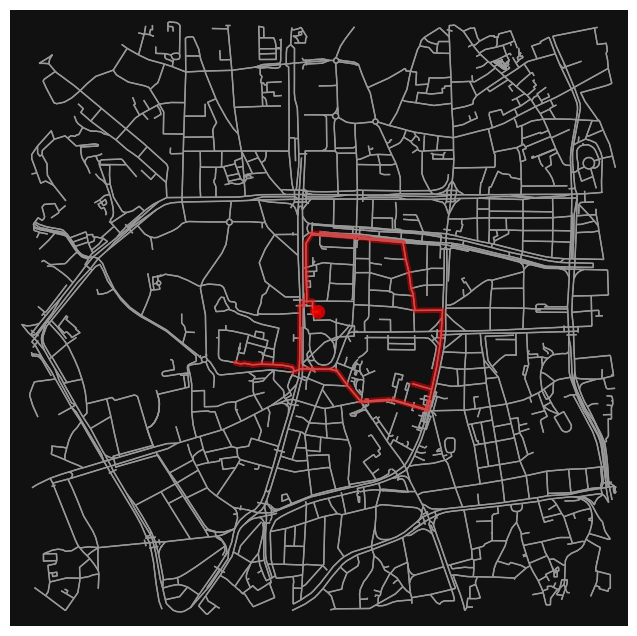

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [116]:
plot_candidate_route(
    final_G,
    final_candidates,
    0
)

In [117]:
locations.extend([
    {"name": "location_6", "lat": 37.5512, "lon": 126.9882},
    {"name": "location_7", "lat": 37.5497, "lon": 126.9140},
    {"name": "location_8", "lat": 37.5563, "lon": 126.9236},
    {"name": "location_9", "lat": 37.5145, "lon": 127.1059},
    {"name": "location_10", "lat": 37.5100, "lon": 127.0632},
])

print("전체 위치:", len(locations))

전체 위치: 10


In [118]:
new_datasets = []

# location_6 ~ location_10만 수집
for location in locations[5:]:
    df = collect_location_dataset(location)

    if df is not None:
        new_datasets.append(df)

print()
print("추가 수집 성공 지역:", len(new_datasets))

location_6 생성 중... (1/3)
  → 실패: "None of [Index(['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio',\n       'residential_ratio', 'major_road_ratio', 'green_ratio', 'radius_min',\n       'radius_max'],\n      dtype='str')] are in the [columns]"
  → 5초 후 재시도
location_6 생성 중... (2/3)
  → 실패: "None of [Index(['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio',\n       'residential_ratio', 'major_road_ratio', 'green_ratio', 'radius_min',\n       'radius_max'],\n      dtype='str')] are in the [columns]"
  → 5초 후 재시도
location_6 생성 중... (3/3)
  → 실패: "None of [Index(['candidate_id', 'distance_m', 'overlap_ratio', 'walkway_ratio',\n       'residential_ratio', 'major_road_ratio', 'green_ratio', 'radius_min',\n       'radius_max'],\n      dtype='str')] are in the [columns]"
  → location_6 수집 실패
location_7 생성 중... (1/3)
  → 후보 경로 22개
location_8 생성 중... (1/3)
  → 실패: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Cau

In [119]:
def create_route_dataframe(G, candidates, green_areas):
    columns = [
        "candidate_id",
        "distance_m",
        "overlap_ratio",
        "walkway_ratio",
        "residential_ratio",
        "major_road_ratio",
        "green_ratio",
        "radius_min",
        "radius_max"
    ]

    # 후보 경로가 하나도 없는 경우
    if not candidates:
        return pd.DataFrame(columns=columns)

    dataset = []

    for i, candidate in enumerate(candidates, start=1):
        features = extract_route_features(
            G,
            candidate["route"],
            green_areas
        )

        features["candidate_id"] = i
        features["radius_min"] = candidate["radius_range"][0]
        features["radius_max"] = candidate["radius_range"][1]

        dataset.append(features)

    return pd.DataFrame(dataset)[columns]

In [120]:
test_df = collect_location_dataset(
    locations[5]
)

print("location_6:", test_df.shape)

location_6 생성 중... (1/3)
  → 후보 경로 0개
location_6: (0, 12)


In [121]:
location_8_df = collect_location_dataset(
    locations[7]
)

if location_8_df is not None:
    print("location_8:", location_8_df.shape)

location_8 생성 중... (1/3)
  → 실패: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x25564b4e390>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))
  → 5초 후 재시도
location_8 생성 중... (2/3)
  → 실패: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x2556688a030>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))
  → 5초 후 재시도
location_8 생성 중... (3/3)
  → 실패: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x25564f6ae40>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))
  → location_8 수집 실패


In [122]:
ox.settings.overpass_url = "https://overpass.kumi.systems/api"

print(ox.settings.overpass_url)

https://overpass.kumi.systems/api


In [123]:
location_8_df = collect_location_dataset(
    locations[7]
)

if location_8_df is not None:
    print("location_8:", location_8_df.shape)

location_8 생성 중... (1/3)
  → 실패: HTTPSConnectionPool(host='overpass.kumi.systems', port=443): Read timed out. (read timeout=180)
  → 5초 후 재시도
location_8 생성 중... (2/3)
  → 실패: HTTPSConnectionPool(host='overpass.kumi.systems', port=443): Read timed out. (read timeout=180)
  → 5초 후 재시도
location_8 생성 중... (3/3)
  → 실패: HTTPSConnectionPool(host='overpass.kumi.systems', port=443): Read timed out. (read timeout=180)
  → location_8 수집 실패


In [124]:
location = locations[7]

test_G, test_start_node = create_walk_graph(
    location["lat"],
    location["lon"]
)

print("그래프 생성 성공")
print("노드:", len(test_G.nodes))
print("엣지:", len(test_G.edges))

ReadTimeout: HTTPSConnectionPool(host='overpass.kumi.systems', port=443): Read timed out. (read timeout=180)

In [125]:
print(len(new_datasets))

for df in new_datasets:
    print(
        df["location_name"].iloc[0]
        if len(df) > 0
        else "empty",
        len(df)
    )

1
location_7 22


In [126]:
new_routes_df = pd.concat(
    new_datasets,
    ignore_index=True
)

all_routes_df = pd.concat(
    [all_routes_df, new_routes_df],
    ignore_index=True
)

print("전체 데이터 개수:", len(all_routes_df))
print("DataFrame 크기:", all_routes_df.shape)

print()
print(
    all_routes_df
    .groupby("location_name")
    .size()
)

전체 데이터 개수: 96
DataFrame 크기: (96, 12)

location_name
location_1    18
location_2    13
location_3     1
location_4    18
location_5    24
location_7    22
dtype: int64


In [127]:
all_routes_df["walk_score"] = pd.NA

print(all_routes_df.shape)
all_routes_df.head()

(96, 13)


,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,green_ratio,radius_min,radius_max,start_latitude,start_longitude,location_name,walk_score
0,1,2730.928761,13.880842,0.380226,0.222703,0.397070,0.882353,250,400,37.5665,126.978,location_1,<NA>
1,2,2674.700526,25.632627,0.423017,0.130036,0.413660,0.875000,250,400,37.5665,126.978,location_1,<NA>
2,3,2690.509777,28.511518,0.365186,0.043697,0.509896,0.830189,250,400,37.5665,126.978,location_1,<NA>
3,4,2562.161982,32.193543,0.355052,0.078702,0.471090,0.794872,250,400,37.5665,126.978,location_1,<NA>
4,5,2597.138900,26.736831,0.350271,0.222854,0.333428,0.800000,250,400,37.5665,126.978,location_1,<NA>


In [128]:
feature_columns = [
    "distance_m",
    "overlap_ratio",
    "walkway_ratio",
    "residential_ratio",
    "major_road_ratio",
    "green_ratio"
]

all_routes_df[feature_columns].describe().round(3)

,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,green_ratio
count,96.000,96.000,96.000,96.000,96.000,96.000
mean,2649.568,22.341,0.253,0.272,0.334,0.504
std,237.843,13.292,0.252,0.235,0.202,0.354
min,2069.631,0.000,0.000,0.000,0.000,0.015
25%,2504.100,12.861,0.059,0.080,0.190,0.125
50%,2678.970,20.477,0.206,0.210,0.309,0.566
75%,2846.438,31.168,0.340,0.379,0.472,0.810
max,2993.461,53.779,1.000,0.976,0.838,1.000


In [129]:
label_columns = [
    "location_name",
    "candidate_id",
    "distance_m",
    "overlap_ratio",
    "walkway_ratio",
    "residential_ratio",
    "major_road_ratio",
    "green_ratio",
    "walk_score"
]

all_routes_df[label_columns].head(10).round(3)

,location_name,candidate_id,distance_m,overlap_ratio,walkway_ratio,residential_ratio,major_road_ratio,green_ratio,walk_score
0,location_1,1,2730.929,13.881,0.380,0.223,0.397,0.882,<NA>
1,location_1,2,2674.701,25.633,0.423,0.130,0.414,0.875,<NA>
2,location_1,3,2690.510,28.512,0.365,0.044,0.510,0.830,<NA>
3,location_1,4,2562.162,32.194,0.355,0.079,0.471,0.795,<NA>
4,location_1,5,2597.139,26.737,0.350,0.223,0.333,0.800,<NA>
5,location_1,6,2508.051,18.763,0.391,0.259,0.317,0.744,<NA>
6,location_1,7,2461.803,22.065,0.049,0.398,0.501,0.667,<NA>
7,location_1,8,2583.485,33.080,0.143,0.302,0.505,0.667,<NA>
8,location_1,9,2181.292,23.081,0.055,0.230,0.715,0.758,<NA>
9,location_1,10,2402.167,34.404,0.233,0.088,0.679,1.000,<NA>


In [130]:
def label_route(df, index, score):
    if score not in [1, 2, 3, 4, 5]:
        print("점수는 1~5 사이로 입력해주세요.")
        return

    df.loc[index, "walk_score"] = score

    row = df.loc[index]

    print(
        f"{row['location_name']} / "
        f"후보 {row['candidate_id']} → "
        f"{score}점 저장"
    )

In [131]:
def label_route(df, index, score):
    if score not in [1, 2, 3, 4, 5]:
        print("점수는 1~5 사이로 입력해주세요.")
        return

    df.loc[index, "walk_score"] = score

    print(
        f"{df.loc[index, 'location_name']} / "
        f"후보 {df.loc[index, 'candidate_id']} → "
        f"{score}점 저장"
    )

In [132]:
label_route(all_routes_df, 0, 5)

location_1 / 후보 1 → 5점 저장


In [133]:
def show_route_for_labeling(df, index):
    row = df.loc[index]

    print(f"Index          : {index}")
    print(f"Location       : {row['location_name']}")
    print(f"Candidate      : {row['candidate_id']}")
    print(f"Distance       : {row['distance_m']:.0f} m")
    print(f"Overlap        : {row['overlap_ratio']:.1f}%")
    print(f"Walkway        : {row['walkway_ratio'] * 100:.1f}%")
    print(f"Residential    : {row['residential_ratio'] * 100:.1f}%")
    print(f"Major Road     : {row['major_road_ratio'] * 100:.1f}%")
    print(f"Green          : {row['green_ratio'] * 100:.1f}%")
    print(f"Walk Score     : {row['walk_score']}")

In [134]:
show_route_for_labeling(
    all_routes_df,
    0
)

Index          : 0
Location       : location_1
Candidate      : 1
Distance       : 2731 m
Overlap        : 13.9%
Walkway        : 38.0%
Residential    : 22.3%
Major Road     : 39.7%
Green          : 88.2%
Walk Score     : 5


In [135]:
def label_next_route(df):
    # 아직 점수가 없는 첫 번째 데이터 찾기
    unlabeled = df[df["walk_score"].isna()]

    if unlabeled.empty:
        print("모든 경로 라벨링 완료")
        return

    index = unlabeled.index[0]

    show_route_for_labeling(df, index)

    score = int(input("\nWalk Score (1~5): "))

    if score not in [1, 2, 3, 4, 5]:
        print("1~5 사이의 점수를 입력해주세요.")
        return

    df.loc[index, "walk_score"] = score

    print(f"\n저장 완료 → index {index}: {score}점")

In [154]:
label_next_route(all_routes_df)

Index          : 19
Location       : location_2
Candidate      : 2
Distance       : 2610 m
Overlap        : 19.7%
Walkway        : 76.8%
Residential    : 0.0%
Major Road     : 0.0%
Green          : 100.0%
Walk Score     : <NA>



Walk Score (1~5):  5



저장 완료 → index 19: 5점


In [155]:
all_routes_df["walk_score"].value_counts().sort_index()

walk_score
1    3
2    7
3    4
4    4
5    2
Name: count, dtype: int64

In [160]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [161]:
labeled_df = all_routes_df[
    all_routes_df["walk_score"].notna()
].copy()

print("라벨링 데이터:", len(labeled_df))

라벨링 데이터: 20


In [162]:
feature_columns = [
    "distance_m",
    "overlap_ratio",
    "walkway_ratio",
    "residential_ratio",
    "major_road_ratio",
    "green_ratio"
]

X = labeled_df[feature_columns]
y = labeled_df["walk_score"].astype(float)

print("X:", X.shape)
print("y:", y.shape)

X: (20, 6)
y: (20,)


In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)

학습 데이터: (16, 6)
테스트 데이터: (4, 6)


In [164]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost 학습 완료")

XGBoost 학습 완료


In [165]:
predictions = model.predict(X_test)

result_df = X_test.copy()
result_df["actual_score"] = y_test
result_df["predicted_score"] = predictions

result_df[["actual_score", "predicted_score"]]

,actual_score,predicted_score
0,5.0,3.956904
17,1.0,1.148916
15,1.0,2.007455
1,4.0,3.956904


In [166]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", round(mae, 3))

MAE: 0.561


In [167]:
unlabeled_df = all_routes_df[
    all_routes_df["walk_score"].isna()
].copy()

X_unlabeled = unlabeled_df[feature_columns]

unlabeled_df["predicted_score"] = model.predict(X_unlabeled)

print("예측 데이터:", len(unlabeled_df))

unlabeled_df[
    ["location_name", "candidate_id", "predicted_score"]
].head(10)

예측 데이터: 76


,location_name,candidate_id,predicted_score
20,location_2,3,4.226363
21,location_2,4,3.088073
22,location_2,5,4.812381
23,location_2,6,3.100973
24,location_2,7,3.088073
25,location_2,8,3.100973
26,location_2,9,4.226363
27,location_2,10,3.956904
28,location_2,11,3.088073
29,location_2,12,3.100973


In [168]:
top_routes = unlabeled_df.sort_values(
    "predicted_score",
    ascending=False
)

top_routes[
    [
        "location_name",
        "candidate_id",
        "distance_m",
        "predicted_score"
    ]
].head(10)

,location_name,candidate_id,distance_m,predicted_score
22,location_2,5,2632.136770,4.812381
93,location_7,20,2633.015031,4.542921
91,location_7,18,2651.454841,4.542921
62,location_5,13,2633.270633,4.542921
30,location_2,13,2937.441401,4.226363
20,location_2,3,2681.589858,4.226363
26,location_2,9,2707.874676,4.226363
40,location_4,9,2571.056905,3.974440
34,location_4,3,2410.759204,3.974440
54,location_5,5,2445.679055,3.974440


In [169]:
top3_by_location = (
    unlabeled_df
    .sort_values(
        ["location_name", "predicted_score"],
        ascending=[True, False]
    )
    .groupby("location_name")
    .head(3)
)

top3_by_location[
    [
        "location_name",
        "candidate_id",
        "distance_m",
        "predicted_score"
    ]
]

,location_name,candidate_id,distance_m,predicted_score
22,location_2,5,2632.136770,4.812381
20,location_2,3,2681.589858,4.226363
26,location_2,9,2707.874676,4.226363
31,location_3,1,2882.580397,3.956904
34,location_4,3,2410.759204,3.974440
40,location_4,9,2571.056905,3.974440
35,location_4,4,2724.704027,3.956904
62,location_5,13,2633.270633,4.542921
54,location_5,5,2445.679055,3.974440
58,location_5,9,2533.352283,3.974440


In [170]:
model.save_model("walk_route_model.json")

print("모델 저장 완료")

모델 저장 완료
